# MLP for Binary Classification on Network Traffic
This notebook trains a Multi-Layer Perceptron (MLP) to classify network flows as benign or malicious using the CIC-DDoS2019 dataset. The input data consists of 100 packets per flow, each with 20 features.

In [2]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from util_functions import load_dataset

2025-09-12 08:44:54.921152: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-12 08:44:55.022330: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-12 08:44:56.784018: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-12 08:45:03.492795: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

## Load Dataset
The dataset is loaded from the DOS2019 folder. Each flow is represented as a 100x20 array.

In [3]:
DATASET_FOLDER = '../DATASETS/FLAD-PCAPS/BASELINE-TOT'
EPOCHS = 100

X_train, y_train = load_dataset(DATASET_FOLDER + '/*-train.hdf5')
X_val, y_val = load_dataset(DATASET_FOLDER + '/*-val.hdf5')
print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:', X_val.shape, y_val.shape)

Train shape: (3111414, 100, 11) (3111414,)
Val shape: (345737, 100, 11) (345737,)


## Build and Train MLP Model
The MLP model flattens the input and uses two dense layers for binary classification.

In [7]:
mlp_model = Sequential()
mlp_model.add(Flatten(input_shape=X_train.shape[1:]))
mlp_model.add(Dense(100, activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))
mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.summary()

/home/rising/EvasionShield-LUCID/tesi/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-09-12 06:59:45.870763: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1100)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       110,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,201 (430.47 KB)

 Trainable params: 110,201 (430.47 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
start_time = time.time()
history = mlp_model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_val, y_val), batch_size=16, verbose=1)
stop_time = time.time()
print('Training time/epoch (sec):', (stop_time-start_time)/EPOCHS)

Epoch 1/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.9833 - loss: 0.0585 - val_accuracy: 0.9984 - val_loss: 0.0098
Epoch 2/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9983 - loss: 0.0104 - val_accuracy: 0.9986 - val_loss: 0.0077
Epoch 3/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9987 - loss: 0.0080 - val_accuracy: 0.9990 - val_loss: 0.0078
Epoch 4/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9989 - loss: 0.0077 - val_accuracy: 0.9993 - val_loss: 0.0073
Epoch 5/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9990 - loss: 0.0068 - val_accuracy: 0.9991 - val_loss: 0.0074
Epoch 6/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step - accuracy: 0.9991 - loss: 0.0066 - val_accuracy: 0.9992 - val_loss: 0.0071
Epoch 7/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9991 - loss: 0.0059 - val_accuracy: 0.9987 - val_loss: 0.0086
Epoch 8/100
24010/24010 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - ac

## Plot Training History

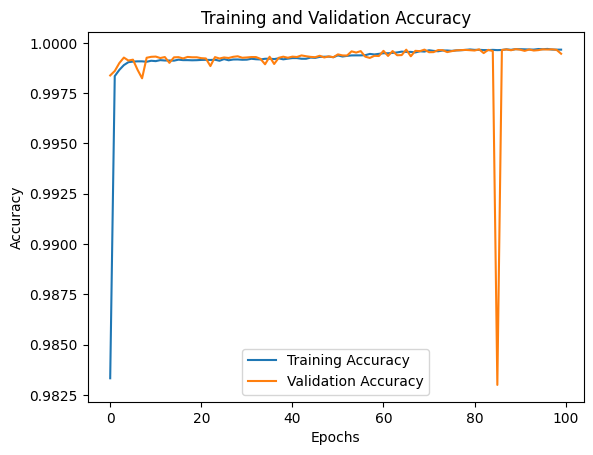

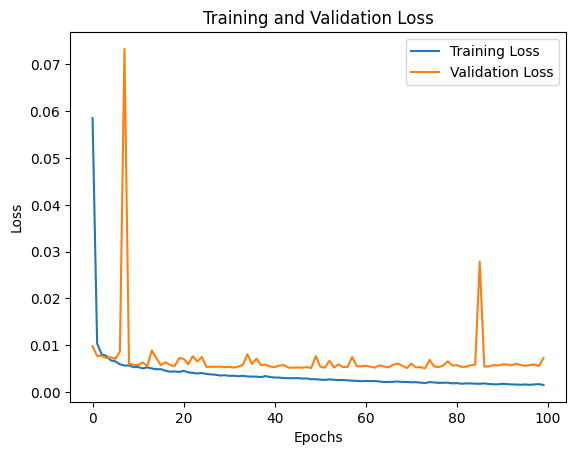

In [9]:
def plot_history(history):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history)

## Evaluate Model Performance

In [12]:
# !pip install scikit-learn
from sklearn.metrics import f1_score, confusion_matrix
y_pred = (mlp_model.predict(X_val) > 0.5).astype(int)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
print('F1 Score:', f1)
print('False Negative Rate:', fnr)
print('False Positive Rate:', fpr)

10805/10805 ━━━━━━━━━━━━━━━━━━━━ 6s 593us/step
F1 Score: 0.9994569205081838
False Negative Rate: 0.0009586564948977529
False Positive Rate: 0.00012747858939146357


## Save and Load Model

In [4]:
# mlp_model.save('mlp_binary_classification.h5')
loaded_model = tf.keras.models.load_model('mlp_binary_classification.h5')
loaded_model.summary()

2025-09-12 08:46:32.508922: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1100)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       110,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,203 (430.48 KB)

 Trainable params: 110,201 (430.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Test Model on Baseline Test Dataset
Now let's test the trained model on the baseline test dataset to evaluate its performance on unseen data.

In [6]:
from sklearn.metrics import f1_score, confusion_matrix
# Load baseline test dataset
X_test_baseline, y_test_baseline = load_dataset(DATASET_FOLDER + '/*-test.hdf5')
print('Baseline Test shape:', X_test_baseline.shape, y_test_baseline.shape)

# Predict on baseline test dataset
y_pred_baseline = (loaded_model.predict(X_test_baseline) > 0.5).astype(int)

# Calculate metrics for baseline test
f1_baseline = f1_score(y_test_baseline, y_pred_baseline)
cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
tn_baseline, fp_baseline, fn_baseline, tp_baseline = cm_baseline.ravel()
fnr_baseline = fn_baseline / (fn_baseline + tp_baseline) if (fn_baseline + tp_baseline) > 0 else 0
fpr_baseline = fp_baseline / (fp_baseline + tn_baseline) if (fp_baseline + tn_baseline) > 0 else 0

print('\n=== Baseline Test Dataset Results ===')
print('F1 Score:', f1_baseline)
print('False Negative Rate:', fnr_baseline)
print('False Positive Rate:', fpr_baseline)
print('Confusion Matrix:')
print(cm_baseline)

Baseline Test shape: (384147, 100, 11) (384147,)
12005/12005 ━━━━━━━━━━━━━━━━━━━━ 7s 601us/step
12005/12005 ━━━━━━━━━━━━━━━━━━━━ 7s 601us/step

=== Baseline Test Dataset Results ===
F1 Score: 0.9995397369178064
False Negative Rate: 0.0008678694849769701
False Positive Rate: 5.184732001202858e-05
Confusion Matrix:
[[192864     10]
 [   166 191107]]

=== Baseline Test Dataset Results ===
F1 Score: 0.9995397369178064
False Negative Rate: 0.0008678694849769701
False Positive Rate: 5.184732001202858e-05
Confusion Matrix:
[[192864     10]
 [   166 191107]]


## Test Model on Manipulated Dataset
Now let's test the model on the manipulated dataset to see how well it performs against adversarial attacks.

In [7]:
# Load manipulated test dataset
MANIPULATED_DATASET_FOLDER = '../DATASETS/MANIPULATED-PCAPS'
X_test_manipulated, y_test_manipulated = load_dataset(MANIPULATED_DATASET_FOLDER + '/*-manipulated-test.hdf5')
print('Manipulated Test shape:', X_test_manipulated.shape, y_test_manipulated.shape)

# Predict on manipulated test dataset
y_pred_manipulated = (loaded_model.predict(X_test_manipulated) > 0.5).astype(int)

# Calculate metrics for manipulated test
f1_manipulated = f1_score(y_test_manipulated, y_pred_manipulated)
cm_manipulated = confusion_matrix(y_test_manipulated, y_pred_manipulated)
tn_manipulated, fp_manipulated, fn_manipulated, tp_manipulated = cm_manipulated.ravel()
fnr_manipulated = fn_manipulated / (fn_manipulated + tp_manipulated) if (fn_manipulated + tp_manipulated) > 0 else 0
fpr_manipulated = fp_manipulated / (fp_manipulated + tn_manipulated) if (fp_manipulated + tn_manipulated) > 0 else 0

print('\n=== Manipulated Test Dataset Results ===')
print('F1 Score:', f1_manipulated)
print('False Negative Rate:', fnr_manipulated)
print('False Positive Rate:', fpr_manipulated)
print('Confusion Matrix:')
print(cm_manipulated)

Manipulated Test shape: (390979, 100, 11) (390979,)
12219/12219 ━━━━━━━━━━━━━━━━━━━━ 7s 598us/step
12219/12219 ━━━━━━━━━━━━━━━━━━━━ 7s 598us/step

=== Manipulated Test Dataset Results ===
F1 Score: 0.988600543512996
False Negative Rate: 0.006081230433910956
False Positive Rate: 0.016676338535780825
Confusion Matrix:
[[193170   3276]
 [  1183 193350]]

=== Manipulated Test Dataset Results ===
F1 Score: 0.988600543512996
False Negative Rate: 0.006081230433910956
False Positive Rate: 0.016676338535780825
Confusion Matrix:
[[193170   3276]
 [  1183 193350]]


## Comparison: Baseline vs Manipulated Test Results
Let's compare the model's performance between the baseline test dataset and the manipulated dataset to assess the impact of adversarial attacks.

In [10]:
# Create comparison table
# !pip install pandas
import pandas as pd

comparison_data = {
    'Metric': ['F1 Score', 'False Negative Rate', 'False Positive Rate', 'True Positives', 'True Negatives', 'False Positives', 'False Negatives'],
    'Baseline Test': [f1_baseline, fnr_baseline, fpr_baseline, tp_baseline, tn_baseline, fp_baseline, fn_baseline],
    'Manipulated Test': [f1_manipulated, fnr_manipulated, fpr_manipulated, tp_manipulated, tn_manipulated, fp_manipulated, fn_manipulated]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Difference'] = comparison_df['Manipulated Test'] - comparison_df['Baseline Test']
comparison_df['% Change'] = ((comparison_df['Manipulated Test'] - comparison_df['Baseline Test']) / comparison_df['Baseline Test'] * 100).round(2)

print('=== Performance Comparison ===')
print(comparison_df.to_string(index=False))

# Calculate performance degradation
f1_degradation = ((f1_baseline - f1_manipulated) / f1_baseline) * 100 if f1_baseline > 0 else 0
fnr_increase = ((fnr_manipulated - fnr_baseline) / fnr_baseline) * 100 if fnr_baseline > 0 else float('inf') if fnr_manipulated > 0 else 0

print(f'\n=== Key Insights ===')
print(f'F1 Score degradation: {f1_degradation:.2f}%')
print(f'False Negative Rate increase: {fnr_increase:.2f}%')
print(f'Model robustness: {"Poor" if f1_degradation > 20 else "Moderate" if f1_degradation > 10 else "Good"}')

=== Performance Comparison ===
             Metric  Baseline Test  Manipulated Test  Difference  % Change
           F1 Score       0.999540          0.988601   -0.010939     -1.09
False Negative Rate       0.000868          0.006081    0.005213    600.71
False Positive Rate       0.000052          0.016676    0.016624  32064.32
     True Positives  191107.000000     193350.000000 2243.000000      1.17
     True Negatives  192864.000000     193170.000000  306.000000      0.16
    False Positives      10.000000       3276.000000 3266.000000  32660.00
    False Negatives     166.000000       1183.000000 1017.000000    612.65

=== Key Insights ===
F1 Score degradation: 1.09%
False Negative Rate increase: 600.71%
Model robustness: Good


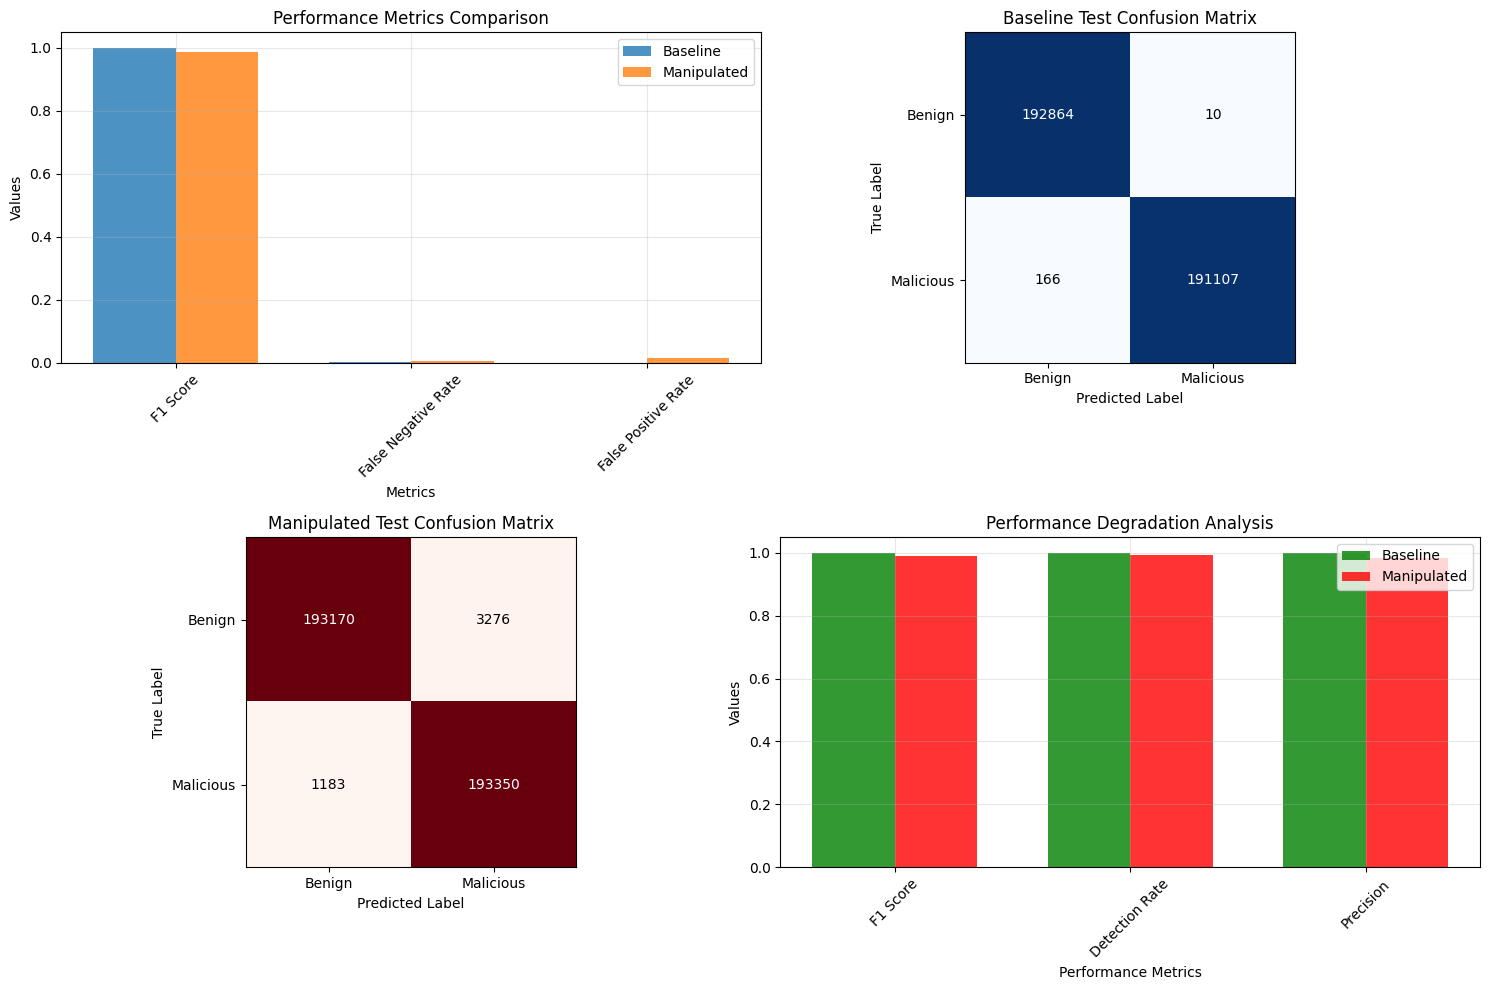

In [11]:
# Visualize the comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# F1 Score comparison
metrics = ['F1 Score', 'False Negative Rate', 'False Positive Rate']
baseline_values = [f1_baseline, fnr_baseline, fpr_baseline]
manipulated_values = [f1_manipulated, fnr_manipulated, fpr_manipulated]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8)
axes[0, 0].bar(x + width/2, manipulated_values, width, label='Manipulated', alpha=0.8)
axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Values')
axes[0, 0].set_title('Performance Metrics Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Confusion Matrix for Baseline
im1 = axes[0, 1].imshow(cm_baseline, interpolation='nearest', cmap=plt.cm.Blues)
axes[0, 1].set_title('Baseline Test Confusion Matrix')
tick_marks = np.arange(2)
axes[0, 1].set_xticks(tick_marks)
axes[0, 1].set_yticks(tick_marks)
axes[0, 1].set_xticklabels(['Benign', 'Malicious'])
axes[0, 1].set_yticklabels(['Benign', 'Malicious'])
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, format(cm_baseline[i, j], 'd'),
                       ha="center", va="center", color="white" if cm_baseline[i, j] > cm_baseline.max() / 2 else "black")

# Confusion Matrix for Manipulated
im2 = axes[1, 0].imshow(cm_manipulated, interpolation='nearest', cmap=plt.cm.Reds)
axes[1, 0].set_title('Manipulated Test Confusion Matrix')
axes[1, 0].set_xticks(tick_marks)
axes[1, 0].set_yticks(tick_marks)
axes[1, 0].set_xticklabels(['Benign', 'Malicious'])
axes[1, 0].set_yticklabels(['Benign', 'Malicious'])
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, format(cm_manipulated[i, j], 'd'),
                       ha="center", va="center", color="white" if cm_manipulated[i, j] > cm_manipulated.max() / 2 else "black")

# Performance degradation visualization
degradation_metrics = ['F1 Score', 'Detection Rate', 'Precision']
baseline_perf = [f1_baseline, 1-fnr_baseline, tp_baseline/(tp_baseline+fp_baseline) if (tp_baseline+fp_baseline) > 0 else 0]
manipulated_perf = [f1_manipulated, 1-fnr_manipulated, tp_manipulated/(tp_manipulated+fp_manipulated) if (tp_manipulated+fp_manipulated) > 0 else 0]

x_deg = np.arange(len(degradation_metrics))
axes[1, 1].bar(x_deg - width/2, baseline_perf, width, label='Baseline', alpha=0.8, color='green')
axes[1, 1].bar(x_deg + width/2, manipulated_perf, width, label='Manipulated', alpha=0.8, color='red')
axes[1, 1].set_xlabel('Performance Metrics')
axes[1, 1].set_ylabel('Values')
axes[1, 1].set_title('Performance Degradation Analysis')
axes[1, 1].set_xticks(x_deg)
axes[1, 1].set_xticklabels(degradation_metrics, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation Function
Define a comprehensive evaluation function that calculates multiple performance metrics including F1 score, accuracy, TPR, TNR, FNR, and FPR for consistent model assessment across different datasets.

In [ ]:
def evaluate_model(model, X_test, y_test, dataset_name):
    """Evaluate model performance and return metrics"""
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    print(f"\n=== {dataset_name} Results ===")
    print(f"F1 Score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"True Positive Rate (TPR): {tpr:.4f}")
    print(f"True Negative Rate (TNR): {tnr:.4f}")
    print(f"False Negative Rate (FNR): {fnr:.4f}")
    print(f"False Positive Rate (FPR): {fpr:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    
    return {
        'dataset': dataset_name,
        'f1': f1,
        'accuracy': accuracy,
        'tpr': tpr,
        'tnr': tnr,
        'fnr': fnr,
        'fpr': fpr,
        'confusion_matrix': cm
    }

## Additional Baseline Test Evaluation
Re-evaluate the model on the baseline test dataset using the comprehensive evaluation function to get detailed metrics for comparison with manipulated data.

In [18]:
# Test on baseline test dataset
try:
    X_test_baseline, y_test_baseline = load_dataset(DATASET_FOLDER + '/*-test.hdf5')
    print(f'Baseline test shape: {X_test_baseline.shape}, {y_test_baseline.shape}')
    baseline_results = evaluate_model(loaded_model, X_test_baseline, y_test_baseline, "Baseline Test")
except Exception as e:
    print(f"Could not load baseline test data: {e}")

Baseline test shape: (384147, 100, 11), (384147,)
12005/12005 ━━━━━━━━━━━━━━━━━━━━ 7s 600us/step

=== Baseline Test Results ===
F1 Score: 0.9995
Accuracy: 0.9995
True Positive Rate (TPR): 0.9991
True Negative Rate (TNR): 0.9999
False Negative Rate (FNR): 0.0009
False Positive Rate (FPR): 0.0001
Confusion Matrix:
[[192864     10]
 [   166 191107]]


## Additional Manipulated Test Evaluation
Evaluate the model on the manipulated test dataset using the comprehensive evaluation function to get detailed metrics for direct comparison with baseline performance.

In [ ]:
# Test on manipulated test dataset
try:
    X_test_manipulated, y_test_manipulated = load_dataset('../DATASETS/MANIPULATED-PCAPS/*-test.hdf5')
    print(f'Manipulated test shape: {X_test_manipulated.shape}, {y_test_manipulated.shape}')
    manipulated_results = evaluate_model(loaded_model, X_test_manipulated, y_test_manipulated, "Manipulated Test")
except Exception as e:
    print(f"Could not load manipulated test data: {e}")


Manipulated test shape: (390979, 100, 11), (390979,)
12219/12219 ━━━━━━━━━━━━━━━━━━━━ 7s 596us/step

=== Manipulated Test Results ===
F1 Score: 0.9886
Accuracy: 0.9886
True Positive Rate (TPR): 0.9939
True Negative Rate (TNR): 0.9833
False Negative Rate (FNR): 0.0061
False Positive Rate (FPR): 0.0167
Confusion Matrix:
[[193170   3276]
 [  1183 193350]]


## Detailed Metrics Comparison
Compare all performance metrics between baseline and manipulated test results with numerical differences and visual representation to understand the impact of adversarial attacks.

=== Baseline Test Results ===
F1: 0.9995
ACCURACY: 0.9995
TPR: 0.9991
TNR: 0.9999
FNR: 0.0009
FPR: 0.0001

=== Manipulated Test Results ===
F1: 0.9886
ACCURACY: 0.9886
TPR: 0.9939
TNR: 0.9833
FNR: 0.0061
FPR: 0.0167

=== Difference (Manipulated - Baseline) ===
F1 Difference: -0.0109
ACCURACY Difference: -0.0109
TPR Difference: -0.0052
TNR Difference: -0.0166
FNR Difference: 0.0052
FPR Difference: 0.0166


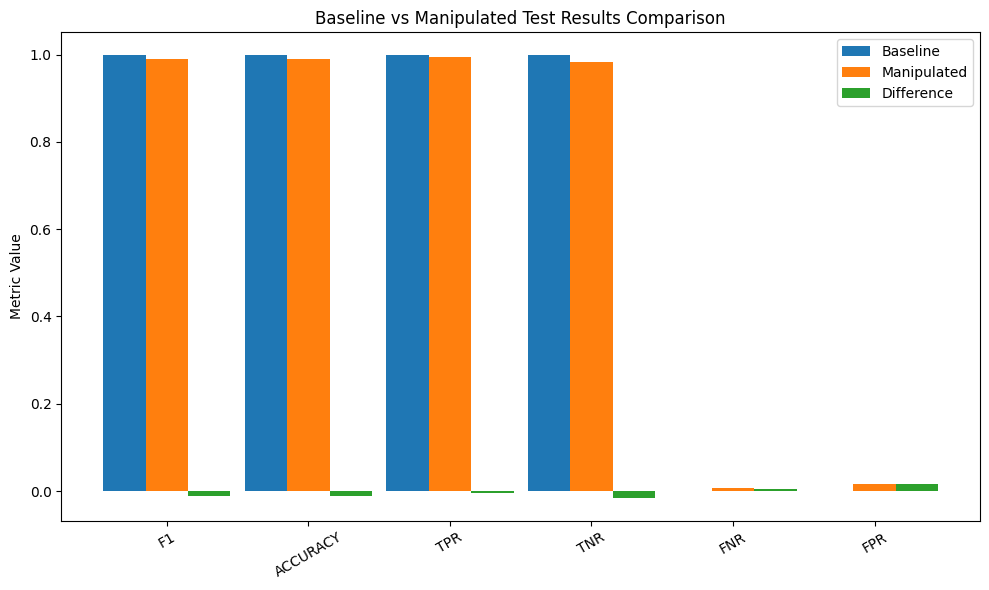

In [20]:
import numpy as np

import matplotlib.pyplot as plt

# Metrics to compare
metrics = ['f1', 'accuracy', 'tpr', 'tnr', 'fnr', 'fpr']
baseline_vals = [baseline_results[m] for m in metrics]
manipulated_vals = [manipulated_results[m] for m in metrics]
diff_vals = [manipulated_results[m] - baseline_results[m] for m in metrics]

# Print results (already in your code)
print("=== Baseline Test Results ===")
for key, val in zip(metrics, baseline_vals):
    print(f"{key.upper()}: {val:.4f}")

print("\n=== Manipulated Test Results ===")
for key, val in zip(metrics, manipulated_vals):
    print(f"{key.upper()}: {val:.4f}")

print("\n=== Difference (Manipulated - Baseline) ===")
for key, val in zip(metrics, diff_vals):
    print(f"{key.upper()} Difference: {val:.4f}")

# Plot comparison
x = np.arange(len(metrics))
width = 0.3

plt.figure(figsize=(10, 6))
plt.bar(x - width, baseline_vals, width, label='Baseline')
plt.bar(x, manipulated_vals, width, label='Manipulated')
plt.bar(x + width, diff_vals, width, label='Difference')
plt.xticks(x, [m.upper() for m in metrics], rotation=30)
plt.ylabel('Metric Value')
plt.title('Baseline vs Manipulated Test Results Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## Attack-Type Specific Evaluation
Analyze model performance on individual DDoS attack types to identify which attacks are most vulnerable to manipulation and cause the highest increase in false positive rates.

=== Testing each attack type individually ===

Loading 00-WebDDoS...
  Baseline shape: (41, 100, 11)
  Manipulated shape: (77, 100, 11)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== 00-WebDDoS Baseline Results ===
F1 Score: 0.9412
Accuracy: 0.9268
True Positive Rate (TPR): 0.8889
True Negative Rate (TNR): 1.0000
False Negative Rate (FNR): 0.1111
False Positive Rate (FPR): 0.0000
Confusion Matrix:
[[14  0]
 [ 3 24]]
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
=== 00-WebDDoS Baseline Results ===
F1 Score: 0.9412
Accuracy: 0.9268
True Positive Rate (TPR): 0.8889
True Negative Rate (TNR): 1.0000
False Negative Rate (FNR): 0.1111
False Positive Rate (FPR): 0.0000
Confusion Matrix:
[[14  0]
 [ 3 24]]
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

=== 00-WebDDoS Manipulated Results ===
F1 Score: 0.2791
Accuracy: 0.5974
True Positive Rate (TPR): 0.1622
True Negative Rate (TNR): 1.0000
False Negative Rate (FNR): 0.8378
False Positive Ra

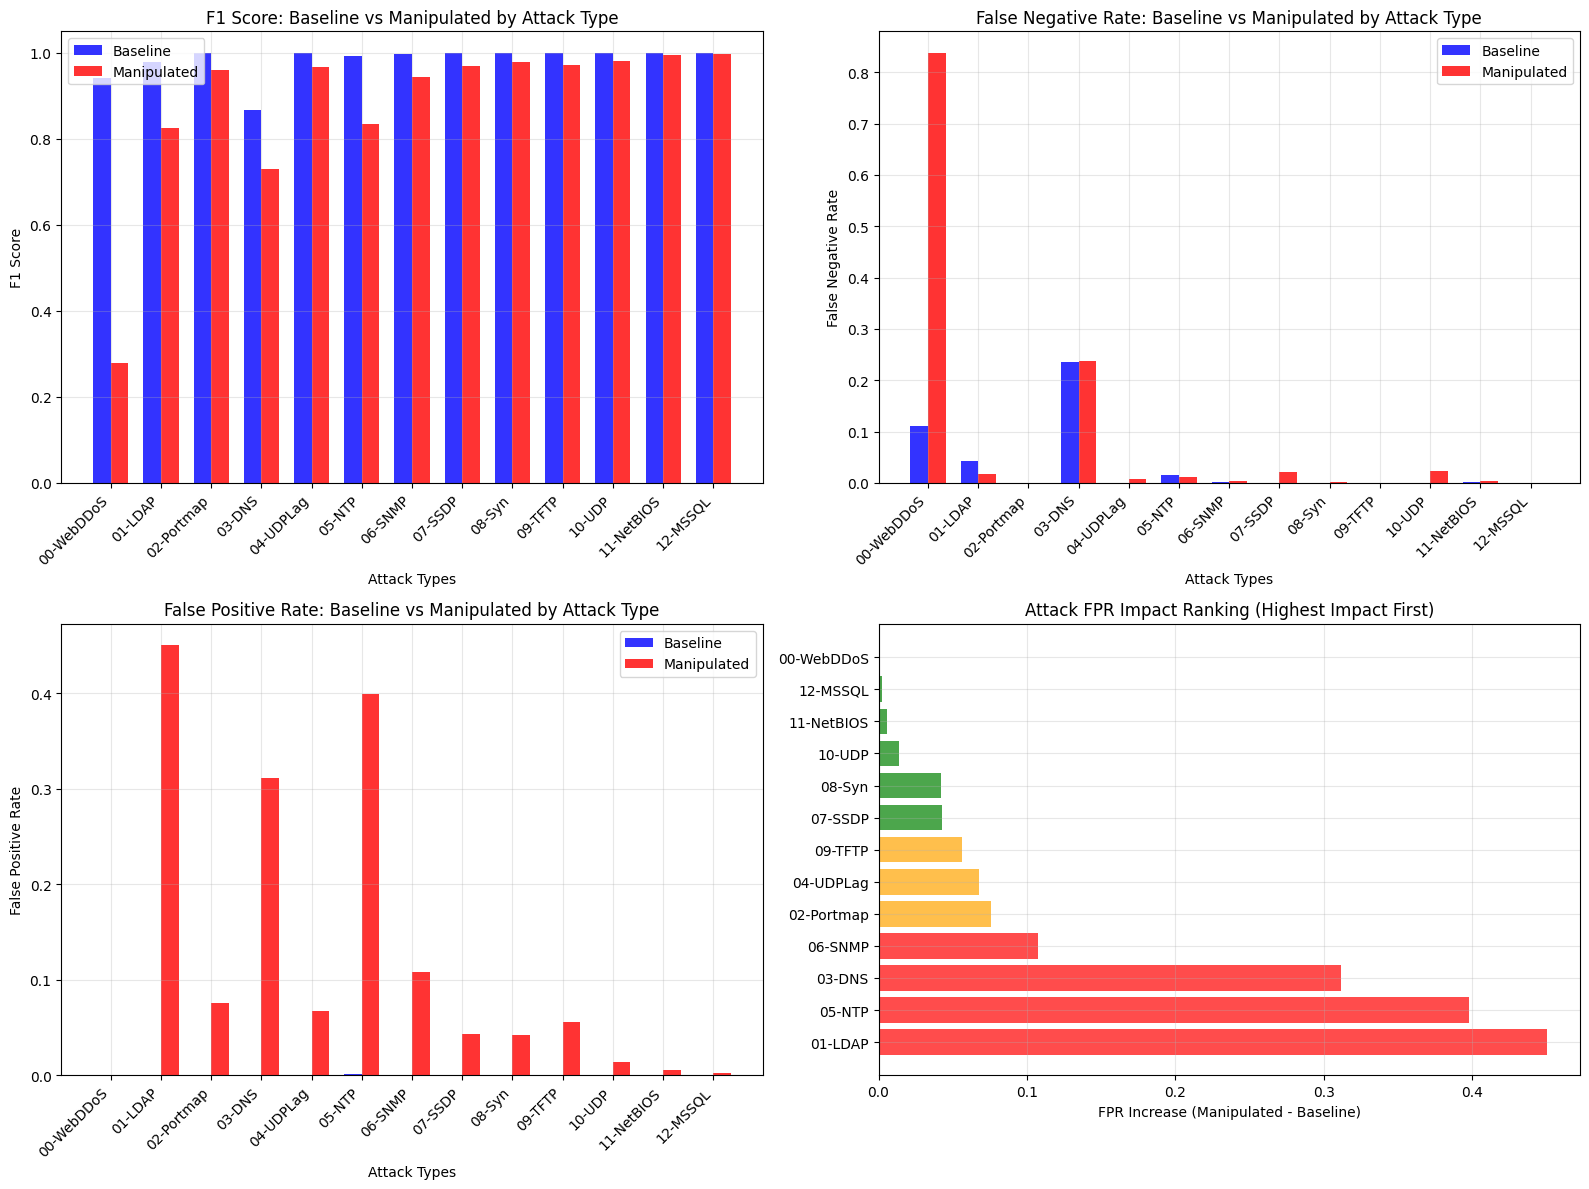

In [30]:
# Attack Type Specific Evaluation
import os

attack_types = ['00-WebDDoS', '01-LDAP', '02-Portmap', '03-DNS', '04-UDPLag', '05-NTP', '06-SNMP', '07-SSDP', '08-Syn', '09-TFTP', '10-UDP', '11-NetBIOS', '12-MSSQL']
attack_baseline_results = []
attack_manipulated_results = []

print("=== Testing each attack type individually ===\n")

for attack in attack_types:
    baseline_path = f'../DATASETS/FLAD-PCAPS/{attack}/10t-100n-DOS2019-dataset-test.hdf5'
    manipulated_path = f'../DATASETS/MANIPULATED-PCAPS/{attack}/10t-100n-DOS2019-dataset-test.hdf5'
    
    try:
        # Check if files exist
        if os.path.exists(baseline_path) and os.path.exists(manipulated_path):
            print(f"Loading {attack}...")
            
            # Load baseline data
            X_base, y_base = load_dataset(baseline_path)
            print(f"  Baseline shape: {X_base.shape}")
            
            # Load manipulated data  
            X_manip, y_manip = load_dataset(manipulated_path)
            print(f"  Manipulated shape: {X_manip.shape}")
            
            # Evaluate on baseline
            res_base = evaluate_model(loaded_model, X_base, y_base, f'{attack} Baseline')
            attack_baseline_results.append(res_base)
            
            # Evaluate on manipulated
            res_manip = evaluate_model(loaded_model, X_manip, y_manip, f'{attack} Manipulated')
            attack_manipulated_results.append(res_manip)
            
            print(f"  ✓ {attack} completed\n")
            
        else:
            print(f"  ✗ Files not found for {attack}")
            if not os.path.exists(baseline_path):
                print(f"    Missing: {baseline_path}")
            if not os.path.exists(manipulated_path):
                print(f"    Missing: {manipulated_path}")
            print()
            
    except Exception as e:
        print(f"  ✗ Error processing {attack}: {e}\n")

print(f"Successfully processed {len(attack_baseline_results)} attack types")

# Create comparison plots if we have results
if len(attack_baseline_results) > 0:
    # Extract attack names and metrics
    attack_names = [r['dataset'].replace(' Baseline', '') for r in attack_baseline_results]
    f1_baseline_attacks = [r['f1'] for r in attack_baseline_results]
    f1_manipulated_attacks = [r['f1'] for r in attack_manipulated_results]
    fnr_baseline_attacks = [r['fnr'] for r in attack_baseline_results]
    fnr_manipulated_attacks = [r['fnr'] for r in attack_manipulated_results]
    
    # Calculate FPR differences for each attack
    fpr_baseline_attacks = [r['fpr'] for r in attack_baseline_results]
    fpr_manipulated_attacks = [r['fpr'] for r in attack_manipulated_results]
    fpr_differences = [fpr_manipulated_attacks[i] - fpr_baseline_attacks[i] for i in range(len(fpr_baseline_attacks))]
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # F1 Score comparison
    x = np.arange(len(attack_names))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, f1_baseline_attacks, width, label='Baseline', alpha=0.8, color='blue')
    axes[0, 0].bar(x + width/2, f1_manipulated_attacks, width, label='Manipulated', alpha=0.8, color='red')
    axes[0, 0].set_xlabel('Attack Types')
    axes[0, 0].set_ylabel('F1 Score')
    axes[0, 0].set_title('F1 Score: Baseline vs Manipulated by Attack Type')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(attack_names, rotation=45, ha='right')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # False Negative Rate comparison
    axes[0, 1].bar(x - width/2, fnr_baseline_attacks, width, label='Baseline', alpha=0.8, color='blue')
    axes[0, 1].bar(x + width/2, fnr_manipulated_attacks, width, label='Manipulated', alpha=0.8, color='red')
    axes[0, 1].set_xlabel('Attack Types')
    axes[0, 1].set_ylabel('False Negative Rate')
    axes[0, 1].set_title('False Negative Rate: Baseline vs Manipulated by Attack Type')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(attack_names, rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # False Positive Rate comparison
    axes[1, 0].bar(x - width/2, fpr_baseline_attacks, width, label='Baseline', alpha=0.8, color='blue')
    axes[1, 0].bar(x + width/2, fpr_manipulated_attacks, width, label='Manipulated', alpha=0.8, color='red')
    axes[1, 0].set_xlabel('Attack Types')
    axes[1, 0].set_ylabel('False Positive Rate')
    axes[1, 0].set_title('False Positive Rate: Baseline vs Manipulated by Attack Type')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(attack_names, rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Attack FPR impact ranking
    attack_fpr_impact = list(zip(attack_names, fpr_differences))
    attack_fpr_impact.sort(key=lambda x: x[1], reverse=True)
    
    impact_names = [item[0] for item in attack_fpr_impact]
    impact_scores = [item[1] for item in attack_fpr_impact]
    impact_colors = ['red' if score > 0.1 else 'orange' if score > 0.05 else 'green' for score in impact_scores]
    
    y_pos = np.arange(len(impact_names))
    axes[1, 1].barh(y_pos, impact_scores, color=impact_colors, alpha=0.7)
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(impact_names)
    axes[1, 1].set_xlabel('FPR Increase (Manipulated - Baseline)')
    axes[1, 1].set_title('Attack FPR Impact Ranking (Highest Impact First)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No attack type data could be loaded for comparison.")

In [ ]:
    # Print summary table
    print("\n=== Attack Type FPR Impact Summary ===")
    print(f"{'Attack Type':<15} {'Baseline FPR':<12} {'Manipulated FPR':<15} {'FPR Increase':<15} {'Impact Level'}")
    print("-" * 75)
    
    for i, attack in enumerate(attack_names):
        impact_level = "High" if fpr_differences[i] > 0.1 else "Medium" if fpr_differences[i] > 0.05 else "Low"
        print(f"{attack:<15} {fpr_baseline_attacks[i]:<12.4f} {fpr_manipulated_attacks[i]:<15.4f} {fpr_differences[i]:<15.4f} {impact_level}")
    
    print(f"\nHighest FPR impact: {impact_names[0]} (+{impact_scores[0]:.4f})")
    print(f"Lowest FPR impact: {impact_names[-1]} (+{impact_scores[-1]:.4f})")


    print("\n===Attack Type FNR Impact Summary===")
    print(f"{'Attack Type':<15} {'Baseline FNR':<12} {'Manipulated FNR':<15} {'FNR Increase':<15} {'Impact Level'}")
    print("-" * 75) 

    for i, attack in enumerate(attack_names):
        fnr_difference = fnr_manipulated_attacks[i] - fnr_baseline_attacks[i]
        impact_level = "High" if fnr_difference > 0.1 else "Medium" if fnr_difference > 0.05 else "Low"
        print(f"{attack:<15} {fnr_baseline_attacks[i]:<12.4f} {fnr_manipulated_attacks[i]:<15.4f} {fnr_difference:<15.4f} {impact_level}")



=== Attack Type FPR Impact Summary ===
Attack Type     Baseline FPR Manipulated FPR FPR Increase    Impact Level
---------------------------------------------------------------------------
00-WebDDoS      0.0000       0.0000          0.0000          Low
01-LDAP         0.0000       0.4502          0.4502          High
02-Portmap      0.0000       0.0759          0.0759          Medium
03-DNS          0.0000       0.3114          0.3114          High
04-UDPLag       0.0000       0.0679          0.0679          Medium
05-NTP          0.0017       0.3995          0.3978          High
06-SNMP         0.0007       0.1080          0.1073          High
07-SSDP         0.0002       0.0432          0.0429          Low
08-Syn          0.0001       0.0423          0.0422          Low
09-TFTP         0.0000       0.0562          0.0562          Medium
10-UDP          0.0001       0.0137          0.0136          Low
11-NetBIOS      0.0000       0.0059          0.0059          Low
12-MSSQL        0